# EOS Table Generator

Inverts the neural-network equation of state (EOS) on an $(\varepsilon, n_B)$ grid.
For each grid point the code solves for $(T, \mu_B, \mu_Q, \mu_S)$ using
damped Newton iterations, then writes the result to `ExampleEOS.dat`.

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.eos_table import EOSNetDeep, Plat, entropy, generate_obs as generate_obs_core, load_eos_model


In [26]:
device = "cpu"
print("Using device:", device)


Using device: cpu


## Rescaling constants

The EOS uses a fixed pressure rescaling of the form
$$P = \beta \cdot P_{\theta}(T,\mu_B,\mu_Q,\mu_S)\,\cdot(T+\Delta T)^2 + P_{\rm lQCD}(T).$$
Those coefficients are defined inside `src.eos_table`, and the notebook only consumes the resulting helper functions.


## Lattice QCD baseline ($\mu_B = 0$)

The baseline pressure is taken from the lattice-QCD fit
$$P_{\rm lQCD}(T) = \chi_0(T)\,T^4$$
with entropy obtained by numerical differentiation,
$$s(T) = \frac{\partial P_{\rm lQCD}}{\partial T}.$$
Both expressions are implemented in `src.eos_table`.


## Neural-network EOS


In [27]:
filename = "model/EOSNetDeep_rezNet.pth"
modelForward = load_eos_model(filename, device=device)
print(f"Loaded {filename}")


Loaded model/EOSNetDeep_rezNet.pth


## Observable generator

All thermodynamic observables follow from the pressure via
standard thermodynamic identities:
$$n_i = \frac{\partial P}{\partial \mu_i}, \qquad
s = \frac{\partial P}{\partial T}, \qquad
\varepsilon = Ts + \sum_i \mu_i n_i - P.$$
The gradient $\partial P/\partial X$ is computed by automatic differentiation through the network plus the analytic lQCD term.

In [28]:
# generate_obs lives in src.eos_table.
def generate_obs(X_tensor):
    return generate_obs_core(X_tensor, modelForward, device=device)


## $(\varepsilon,\, n_B)$ grid

The EOS table is built on a uniform grid in $\varepsilon$ and $n_B$.  
The isospin and strangeness constraints
$$n_Q = 0.4\,n_B, \qquad n_S = 0$$
are imposed inside `eval_F` to match the isospin-symmetric nuclear matter condition ($Z/A \approx 0.4$).

Define `eps_vals` and `nB_vals` (in fm$^{-4}$) before running the next cell.


In [29]:
# Define the grid ranges here ---------------------------------------------------
# eps_vals = np.linspace(...)   # energy density  [GeV fm^{-3}]
# nB_vals  = np.linspace(...)   # baryon density  [fm^{-3}]
# ------------------------------------------------------------------------------


# test
eps_vals = np.linspace(0, 1.0, 21)  
nB_vals  = np.linspace(-0.1, 0.6, 29) 

# Near particlization region
# eps_vals = np.arange(0.00, 0.8 + 1e-6, 0.005)
# nB_vals  = np.arange(-0.1, 0.8 + 1e-6, 0.005)

# # Hydrodynamic region
# eps_vals = np.arange(0.00, 80.0+1e-6, 0.1)
# nB_vals  = np.arange(-0.5, 8.0+1e-6, 0.05)


EPS, NB = np.meshgrid(eps_vals, nB_vals, indexing="ij")
eps_sel  = EPS.reshape(-1)
nB_sel   = NB.reshape(-1)
print(f"Grid shape: {EPS.shape}  |  total points: {len(eps_sel)}")

# Flatten to 1-D target arrays for the inversion
eps_target = torch.tensor(eps_sel, dtype=torch.float32, device=device)
nB_target  = torch.tensor(nB_sel,  dtype=torch.float32, device=device)


Grid shape: (21, 29)  |  total points: 609


## Newton inversion

For each grid point $(\varepsilon^*, n_B^*)$ we solve the nonlinear system
$$F(T,\mu_B,\mu_Q,\mu_S) = \begin{pmatrix} \varepsilon - \varepsilon^* \\\\ n_B - n_B^* \\\\ n_Q - 0.4\,n_B \\\\ n_S \end{pmatrix} = 0$$
with damped Newton steps. The Jacobian is computed by finite differences across the full batch in parallel.


In [30]:
# ── residual vector ───────────────────────────────────────────────────────────
def eval_F(x):
    obs = generate_obs(x)
    eps, nB, nQ, nS = obs[:, 0], obs[:, 1], obs[:, 2], obs[:, 3]
    return torch.stack([
        eps - eps_target,
        nB  - nB_target,
        nQ  - 0.4 * nB,   # isospin constraint
        nS,                # strangeness neutrality
    ], dim=1).to(dtype=torch.float32)


# ── finite-difference Jacobian (batched over all grid points) ─────────────────
def jacobian_fd(x, h=1e-2):
    N, D = x.shape
    J = torch.zeros(N, D, D, device=device, dtype=torch.float32)
    for i in range(D):
        dx = torch.zeros_like(x)
        dx[:, i] = h
        J[:, :, i] = (eval_F(x + dx) - eval_F(x - dx)) / (2 * h)
    return J


# ── initial guess ─────────────────────────────────────────────────────────────
x = torch.zeros((len(eps_sel), 4), device=device, dtype=torch.float32)
x[:, 0] = 0.15   # T    [GeV]
x[:, 1] = 0.40   # muB  [GeV]
x[:, 2] = 0.00   # muQ  [GeV]
x[:, 3] = 0.00   # muS  [GeV]

# ── damped Newton loop ────────────────────────────────────────────────────────
MAX_ITER = 50
DAMPING  = 0.5    # step size < 1 prevents overshooting in highly nonlinear regions

for q in range(MAX_ITER):
    F = eval_F(x)
    J = jacobian_fd(x)
    dx = torch.linalg.solve(J, F.unsqueeze(-1)).squeeze(-1)
    x  = x - DAMPING * dx

    # hard bounds keep x inside the training domain of the network
    x[:, 0].clamp_(0.02, 0.60)   # T
    x[:, 1].clamp_(-0.05, 1.05)  # muB
    x[:, 2].clamp_(-0.05, 0.05)  # muQ
    x[:, 3].clamp_(-0.05, 0.40)  # muS

    res_norm  = F.detach().cpu().numpy()
    res_norm  = np.linalg.norm(res_norm, axis=1)
    good_mask = res_norm < 1e-3

    if q % 10 == 0:
        print(f"iter {q:2d}  |  max={res_norm.max():.2e}  mean={res_norm.mean():.2e}"
              f"  |  converged: {good_mask.sum()}/{len(res_norm)}")

    if good_mask.all() and res_norm.max() < 1e-6:
        print("All points converged.")
        break

T_sol, muB_sol, muQ_sol, muS_sol = x.T.detach().cpu().numpy()
residual_norm = np.linalg.norm(eval_F(x).detach().cpu().numpy(), axis=1)

good = residual_norm < 1e-3
print(f"\nFinal: {good.mean():.1%} of points converged"
      f"  |  mean residual {residual_norm[good].mean():.2e}"
      f"  |  max residual {residual_norm[good].max():.2e}")


iter  0  |  max=6.70e-01  mean=3.65e-01  |  converged: 0/609
iter 10  |  max=2.27e+02  mean=6.75e+00  |  converged: 316/609
iter 20  |  max=2.27e+02  mean=1.46e+00  |  converged: 374/609
iter 30  |  max=2.27e+02  mean=1.88e+00  |  converged: 374/609
iter 40  |  max=2.39e+02  mean=4.36e+00  |  converged: 375/609

Final: 61.4% of points converged  |  mean residual 2.08e-07  |  max residual 2.44e-05


## Diagnostic: converged points

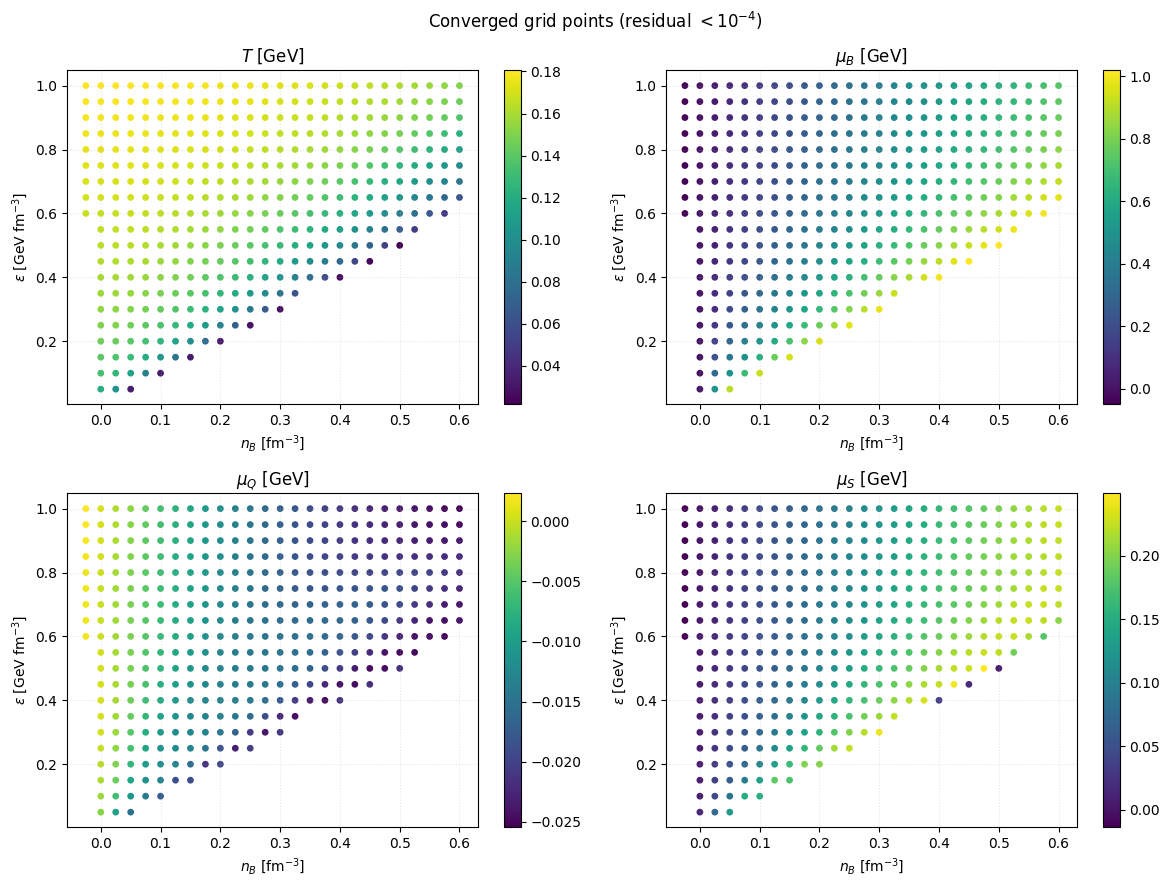

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
good = residual_norm < 1e-4   # tighter cut for the plot

def panel(ax, c, title):
    sc = ax.scatter(nB_sel[good], eps_sel[good], c=c[good], cmap="viridis", s=15)
    plt.colorbar(sc, ax=ax)
    ax.set(title=title, xlabel=r"$n_B$ [fm$^{-3}$]", ylabel=r"$\varepsilon$ [GeV fm$^{-3}$]")
    ax.grid(linestyle=":", alpha=0.3)

panel(axes[0, 0], T_sol,   r"$T$ [GeV]")
panel(axes[0, 1], muB_sol, r"$\mu_B$ [GeV]")
panel(axes[1, 0], muQ_sol, r"$\mu_Q$ [GeV]")
panel(axes[1, 1], muS_sol, r"$\mu_S$ [GeV]")

plt.suptitle("Converged grid points (residual $< 10^{-4}$)")
plt.tight_layout()
plt.show()


## Nearest-neighbour fallback for unconverged points

Points that did not converge are seeded from the nearest converged neighbour
in $(\varepsilon, n_B)$ space and the Newton loop is re-run. This avoids holes
in the table while keeping the residual small almost everywhere.


In [32]:
bad_mask  = residual_norm >= 1e-4
good_idx  = np.where(~bad_mask)[0]

if bad_mask.any() and len(good_idx) > 0:
    x_np   = x.detach().cpu().numpy()
    coords = np.stack([eps_sel, nB_sel], axis=1)

    for i in np.where(bad_mask)[0]:
        d       = np.sum((coords[good_idx] - coords[i]) ** 2, axis=1)
        nearest = good_idx[np.argmin(d)]
        x_np[i] = x_np[nearest]   # warm-start from closest good solution

    x = torch.tensor(x_np, device=device, dtype=torch.float32)
    print(f"Re-seeded {bad_mask.sum()} unconverged points.")


Re-seeded 235 unconverged points.


In [33]:
# # optional second pass after re-seeding
# for q in range(10):
#     print('step:', q)
#     F  = eval_F(x)
#     J  = jacobian_fd(x)
#     dx = torch.linalg.solve(J, F.unsqueeze(-1)).squeeze(-1)
#     x  = x - DAMPING * dx
#     x[:, 0].clamp_(0.02, 0.60)
#     x[:, 1].clamp_(-0.05, 1.05)
#     x[:, 2].clamp_(-0.05, 0.05)
#     x[:, 3].clamp_(-0.05, 0.40)
#     res_norm  = np.linalg.norm(F.detach().cpu().numpy(), axis=1)
#     if res_norm.max() < 1e-6:
#         break
# print(f"After re-seed pass: max residual {res_norm.max():.2e}")


## Final solution over the full grid

In [34]:
good_mask = res_norm < 1e-3
bad_mask  = ~good_mask

good_idx = np.where(good_mask)[0]

if len(good_idx) > 0 and bad_mask.any():

    x_np = x.detach().cpu().numpy()

    for i in np.where(bad_mask)[0]:

        # good points with same epsilon
        same_eps_idx = good_idx[eps_sel[good_idx] == eps_sel[i]]

        # skip if no valid point on this epsilon line
        if len(same_eps_idx) == 0:
            continue

        # candidate points with |nB| strictly smaller than the bad point
        smaller_abs_nB = same_eps_idx[
            np.abs(nB_sel[same_eps_idx]) < np.abs(nB_sel[i])
        ]

        if len(smaller_abs_nB) > 0:
            # among those, pick the one closest in |nB| to the bad point
            d = (np.abs(nB_sel[smaller_abs_nB]) - np.abs(nB_sel[i])) ** 2
            nearest = smaller_abs_nB[np.argmin(d)]
        else:
            # fallback: nearest converged point on same epsilon line (any nB)
            d = (nB_sel[same_eps_idx] - nB_sel[i]) ** 2
            nearest = same_eps_idx[np.argmin(d)]

        # replace bad solution
        x_np[i] = x_np[nearest]

    x = torch.tensor(x_np, device=device, dtype=torch.float32)


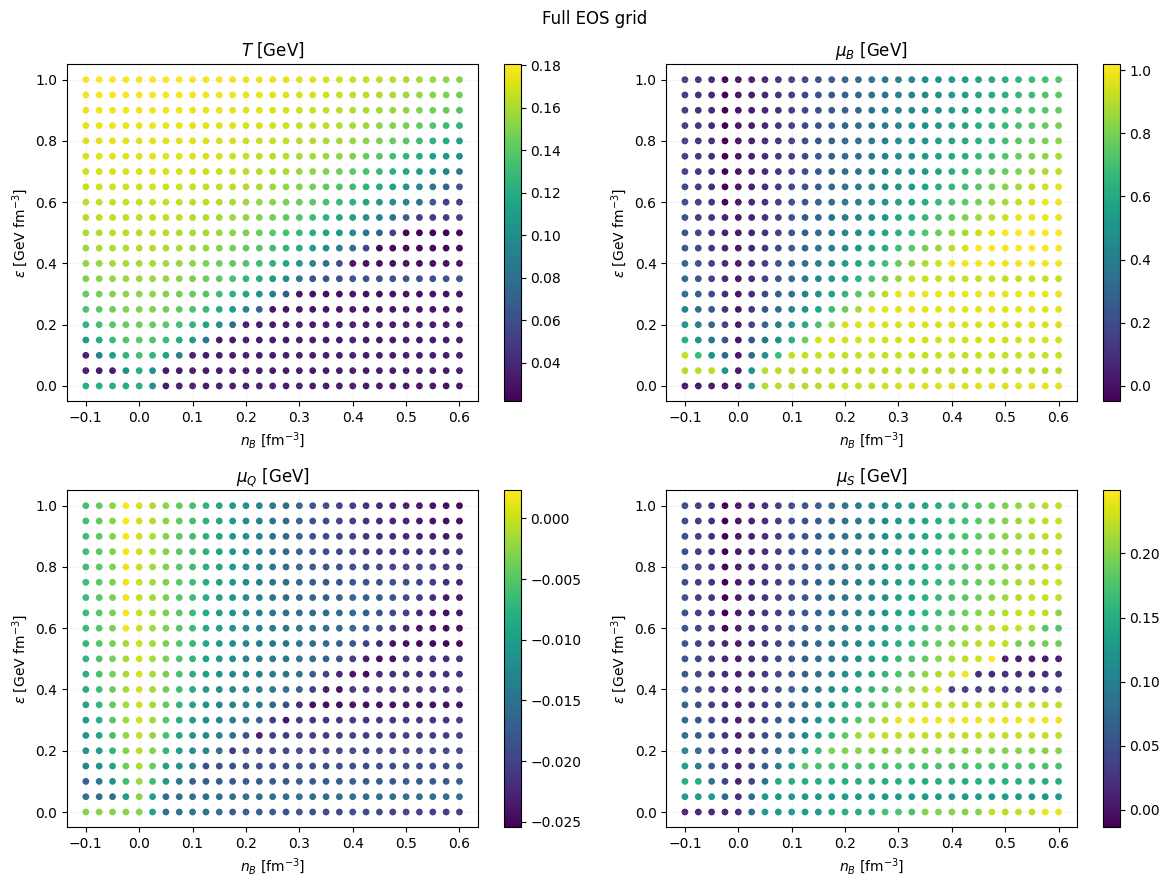

In [35]:
T_sol   = x[:, 0].detach().cpu().numpy()
muB_sol = x[:, 1].detach().cpu().numpy()
muQ_sol = x[:, 2].detach().cpu().numpy()
muS_sol = x[:, 3].detach().cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

def panel(ax, c, title):
    sc = ax.scatter(nB_sel, eps_sel, c=c, cmap="viridis", s=15)
    plt.colorbar(sc, ax=ax)
    ax.set(title=title, xlabel=r"$n_B$ [fm$^{-3}$]", ylabel=r"$\varepsilon$ [GeV fm$^{-3}$]")
    ax.grid(linestyle=":", alpha=0.3)

panel(axes[0, 0], T_sol,   r"$T$ [GeV]")
panel(axes[0, 1], muB_sol, r"$\mu_B$ [GeV]")
panel(axes[1, 0], muQ_sol, r"$\mu_Q$ [GeV]")
panel(axes[1, 1], muS_sol, r"$\mu_S$ [GeV]")

plt.suptitle("Full EOS grid")
plt.tight_layout()
plt.show()


## Vacuum boundary condition and output

At $\varepsilon \to 0$ the EOS must approach the vacuum ($T=0$, $P=0$).
Points below $\varepsilon < 10^{-4}\, \text{GeV}\ \text{fm}^{-3}$ are set to vacuum by hand
before writing the table.

Output columns: `T  muB  eps  nB  muQ  muS  P  residual`


In [36]:
x_tensor = torch.tensor(
    np.stack([T_sol, muB_sol, muQ_sol, muS_sol], axis=1),
    dtype=torch.float32, device=device
)

vacuum_mask = eps_target < 1e-4

# zero out temperature in the vacuum region
T_vac = torch.where(vacuum_mask, torch.zeros_like(x_tensor[:, 0]), x_tensor[:, 0])
x_fixed = torch.stack([T_vac, x_tensor[:, 1], x_tensor[:, 2], x_tensor[:, 3]], dim=1)

obs     = generate_obs(x_fixed)
P_model = obs[:, 4]
F_final = eval_F(x_fixed)
res     = torch.linalg.norm(F_final, dim=1)

# enforce P = 0 in vacuum; mark vacuum residual as 1 (trivially satisfied)
P_model = torch.where(vacuum_mask, torch.zeros_like(P_model), P_model)
res     = torch.where(vacuum_mask, torch.ones_like(res), res)

out = torch.stack([
    T_vac, x_tensor[:, 1],   # T, muB
    eps_target, nB_target,    # grid values kept exact
    x_tensor[:, 2], x_tensor[:, 3],  # muQ, muS
    P_model, res
], dim=1).detach().cpu().numpy()

# sort by (nB, eps) for a structured table
order = np.lexsort((out[:, 2], out[:, 3]))
out   = out[order]

np.savetxt("ExampleEOS.dat", out, fmt="%.6f",
           header="T[GeV]  muB[GeV]  eps[GeV/fm^3]  nB[1/fm^3]  muQ[GeV]  muS[GeV]  P[GeV/fm^3]  residual")
print("Saved: ExampleEOS.dat")


Saved: ExampleEOS.dat
